In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/violence_detection_project"
DATASET_ROOT = f"{PROJECT_ROOT}/dataset/kaggle/input/rwf2000/RWF-2000"

TRAIN_DIR = f"{DATASET_ROOT}/train"
VAL_DIR   = f"{DATASET_ROOT}/val"
TEST_DIR  = f"{DATASET_ROOT}/test"


In [ ]:
from ultralytics import YOLO
yolo = YOLO("yolov8n.pt")
print("YOLO loaded")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO loaded


In [ ]:
import os

def build_video_list(root_dir):
    video_list = []
    label_map = {"NonFight": 0, "Fight": 1}
    for label_name, label in label_map.items():
        class_dir = os.path.join(root_dir, label_name)
        for video in os.listdir(class_dir):
            if video.endswith(".avi"):
                video_list.append(
                    (os.path.join(class_dir, video), label)
                )
    return video_list

train_videos = build_video_list(TRAIN_DIR)
val_videos   = build_video_list(VAL_DIR)
test_videos  = build_video_list(TEST_DIR)

len(train_videos), len(val_videos), len(test_videos)


(1600, 400, 20)

In [ ]:
import cv2

def get_total_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return total


In [ ]:
import numpy as np

def get_tsn_indices(total_frames, num_segments, mode):
    segment_length = total_frames // num_segments
    indices = []

    for i in range(num_segments):
        start = i * segment_length
        if mode == "train":
            offset = np.random.randint(0, segment_length)
        else:
            offset = segment_length // 2
        indices.append(start + offset)

    return indices


In [ ]:
def extract_tsn_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(video_path)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError(f"Failed to read frame {idx}")
        frames.append(frame)
    cap.release()
    return frames


In [ ]:
def apply_human_mask(frame, yolo_model, dim_factor=0.3):
    """
    Dims the background and keeps detected human regions bright.
    frame: HxWx3 BGR numpy array
    Returns: HxWx3 BGR numpy array
    """
    h, w = frame.shape[:2]

    # Run YOLO detection
    results = yolo_model(frame, verbose=False)
    boxes   = results[0].boxes

    # Start with a dim mask (dim_factor = how bright background stays)
    mask = np.full((h, w), dim_factor, dtype=np.float32)

    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            # Only keep person class (class 0 in COCO)
            if int(box.cls) != 0:
                continue
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # Clamp to frame boundaries
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            # Set human region to full brightness
            mask[y1:y2, x1:x2] = 1.0

    # Expand mask to 3 channels and apply
    mask = np.stack([mask, mask, mask], axis=2)  # [H, W, 3]
    masked_frame = (frame.astype(np.float32) * mask).astype(np.uint8)

    return masked_frame


In [ ]:
import torchvision.transforms as T

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def frame_to_tensor(frame, transform=None):
    if len(frame.shape) == 2:
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    else:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    if transform is not None:
        return transform(frame)

    # Fallback: no augmentation
    frame = cv2.resize(frame, (224, 224))
    frame = frame.astype(np.float32) / 255.0
    frame = torch.from_numpy(frame).permute(2, 0, 1)
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (frame - MEAN) / STD


In [ ]:
from torch.utils.data import Dataset

class TSNDataset(Dataset):
    def __init__(self, video_list, num_segments=8, mode="train"):
        self.video_list   = video_list
        self.num_segments = num_segments
        self.mode         = mode
        self.transform    = val_transform

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_path, label = self.video_list[idx]
        total_frames  = get_total_frames(video_path)
        frame_indices = get_tsn_indices(total_frames, self.num_segments, self.mode)

        frames = extract_tsn_frames(video_path, frame_indices)

        tsn_frames = []
        for f in frames:
            masked = apply_human_mask(f, yolo)
            tsn_frames.append(frame_to_tensor(masked, self.transform))

        tsn_tensor = torch.stack(tsn_frames)
        return tsn_tensor, label


In [ ]:
from torch.utils.data import DataLoader

train_dataset = TSNDataset(train_videos, num_segments=8, mode="train")
val_dataset   = TSNDataset(val_videos,   num_segments=8, mode="val")
test_dataset  = TSNDataset(test_videos,  num_segments=8, mode="test")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

print(len(train_dataset), len(val_dataset), len(test_dataset))

1600 400 20


In [ ]:
import torch.nn as nn
from torchvision import models

class TSNModel(nn.Module):
    def __init__(self, num_classes=2, backbone_name="resnet18", pretrained=True):
        super().__init__()
        if backbone_name == "resnet18":
            backbone = models.resnet18(pretrained=pretrained)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Linear(in_features, num_classes)
        else:
            raise ValueError("Unsupported Backbone")
        self.backbone    = backbone
        self.num_classes = num_classes

    def forward(self, x):
        B, K, C, H, W = x.shape
        x = x.view(B*K, C, H, W)
        logits = self.backbone(x)
        logits = logits.view(B, K, self.num_classes)
        return logits.mean(dim=1)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for videos, labels in loader:
        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


In [ ]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSNModel(num_classes=2, pretrained=False).to(device)
model.load_state_dict(
    torch.load(f"{PROJECT_ROOT}/tsn_best.pth", map_location=device)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

print("Model loaded from tsn_best.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from tsn_best.pth


In [ ]:
best_val_acc = 0.0
num_epochs   = 5

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{PROJECT_ROOT}/tsn_masked_best.pth")
        print(f"  >>> New best saved: val_acc={val_acc:.4f}")

print(f"Done. Best Val Acc = {best_val_acc:.4f}")


Epoch 1/5 | Train Loss: 0.4906 | Train Acc: 0.7662 | Val Loss: 0.5165 | Val Acc: 0.7025
  >>> New best saved: val_acc=0.7025
Epoch 2/5 | Train Loss: 0.4145 | Train Acc: 0.8200 | Val Loss: 0.5692 | Val Acc: 0.6875
Epoch 3/5 | Train Loss: 0.3719 | Train Acc: 0.8319 | Val Loss: 0.5398 | Val Acc: 0.7000
Epoch 4/5 | Train Loss: 0.3354 | Train Acc: 0.8494 | Val Loss: 0.5201 | Val Acc: 0.7500
  >>> New best saved: val_acc=0.7500
Epoch 5/5 | Train Loss: 0.3132 | Train Acc: 0.8638 | Val Loss: 0.5190 | Val Acc: 0.7275
Done. Best Val Acc = 0.7500


In [ ]:
model.load_state_dict(
    torch.load(f"{PROJECT_ROOT}/tsn_masked_best.pth", map_location=device)
)
model.eval()
print("Best model loaded")


Best model loaded


In [ ]:
def evaluate(model, loader, device):
    model.eval()
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            preds   = outputs.argmax(dim=1)

            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, all_preds, all_labels


Validation Accuracy: 0.75


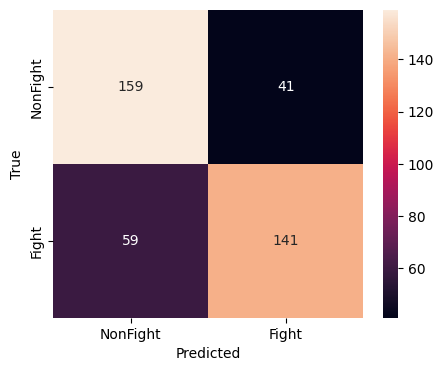

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

val_acc, preds, labels = evaluate(model, val_loader, device)
print("Validation Accuracy:", val_acc)

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["NonFight", "Fight"],
            yticklabels=["NonFight", "Fight"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
def evaluate_verbose(model, loader, device):
    model.eval()
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    label_map = {0: "NonFight", 1: "Fight"}

    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            preds   = outputs.argmax(dim=1)

            for i in range(len(labels)):
                pred_label  = label_map[preds[i].item()]
                true_label  = label_map[labels[i].item()]
                correct_str = "✓" if preds[i] == labels[i] else "✗"
                print(f"[{total + i + 1}] Predicted: {pred_label:<10} | Actual: {true_label:<10} | {correct_str}")

            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"\nTest Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy, all_preds, all_labels

test_acc, test_preds, test_labels = evaluate_verbose(model, test_loader, device)


[1] Predicted: NonFight   | Actual: NonFight   | ✓
[2] Predicted: Fight      | Actual: NonFight   | ✗
[3] Predicted: Fight      | Actual: NonFight   | ✗
[4] Predicted: Fight      | Actual: NonFight   | ✗
[5] Predicted: NonFight   | Actual: NonFight   | ✓
[6] Predicted: NonFight   | Actual: NonFight   | ✓
[7] Predicted: NonFight   | Actual: NonFight   | ✓
[8] Predicted: NonFight   | Actual: NonFight   | ✓
[9] Predicted: Fight      | Actual: NonFight   | ✗
[10] Predicted: NonFight   | Actual: NonFight   | ✓
[11] Predicted: NonFight   | Actual: Fight      | ✗
[12] Predicted: Fight      | Actual: Fight      | ✓
[13] Predicted: Fight      | Actual: Fight      | ✓
[14] Predicted: Fight      | Actual: Fight      | ✓
[15] Predicted: NonFight   | Actual: Fight      | ✗
[16] Predicted: Fight      | Actual: Fight      | ✓
[17] Predicted: Fight      | Actual: Fight      | ✓
[18] Predicted: Fight      | Actual: Fight      | ✓
[19] Predicted: Fight      | Actual: Fight      | ✓
[20] Predicted: Fight